In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
df = pd.read_excel("/content/onlinefraud.csv.xlsx")

In [ ]:
#Basic dataset statistics
eda_summary = {
    "shape": df.shape,
    "data_types": df.dtypes,
    "missing_values": df.isnull().sum(),
    "summary_stats": df.describe(),
    "fraud_counts": df["isFraud"].value_counts(),
    "fraud_percent": df["isFraud"].value_counts(normalize=True) * 100,
    "transaction_types": df["type"].value_counts()
}

In [ ]:
# Display each part of the summary
print("🧾 Shape of the dataset:")
print(eda_summary["shape"])
print("\n📦 Data types:")
print(eda_summary["data_types"])
print("\n🔍 Missing values:")
print(eda_summary["missing_values"])
print("\n📊 Summary statistics (numerical columns):")
print(eda_summary["summary_stats"])
print("\n🚨 Fraud counts:")
print(eda_summary["fraud_counts"])
print("\n📈 Fraud percentage:")
print(eda_summary["fraud_percent"])
print("\n💳 Transaction type distribution:")
print(eda_summary["transaction_types"])

🧾 Shape of the dataset:
(1048575, 11)

📦 Data types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

🔍 Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

📊 Summary statistics (numerical columns):
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  1.048575e+06  1.048575e+06   1.048575e+06    1.048575e+06   
mean   2.696617e+01  1.586670e+05   8.740055e+05    8.938049e+05   
std    1.562325e+01  2.649409e+05   2.971725e+06    3.008246e+06   
min    1.000000e+00  1.000000e-01   0.000000e+00    0.000000e+00   
25%    1.500

In [ ]:
# Detecting outliers via IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [ ]:
# Applying to relevant numeric columns
for col in ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']:
    outliers, low, high = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers between {low} and {high}")

amount: 53088 outliers between -290270.17250000004 and 516181.12750000006
oldbalanceOrg: 181877 outliers between -204963.03000000003 and 341605.05000000005
newbalanceOrig: 170244 outliers between -261899.985 and 436499.975
oldbalanceDest: 125403 outliers between -1373885.2125 and 2289808.6875
newbalanceDest: 114557 outliers between -1724711.2649999997 and 2874518.7749999994


In [ ]:
# Fraud analysis by type
fraud_by_type = df[df['isFraud'] == 1]['type'].value_counts()
fraud_by_type_percent = fraud_by_type / df['type'].value_counts() * 100

In [ ]:
# Print results
print("🔍 Fraud Count by Transaction Type:")
print(fraud_by_type)

print("\n📊 Fraud Percentage by Transaction Type:")
print(fraud_by_type_percent)


🔍 Fraud Count by Transaction Type:
type
CASH_OUT    578
TRANSFER    564
Name: count, dtype: int64

📊 Fraud Percentage by Transaction Type:
type
CASH_IN          NaN
CASH_OUT    0.154694
DEBIT            NaN
PAYMENT          NaN
TRANSFER    0.650122
Name: count, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

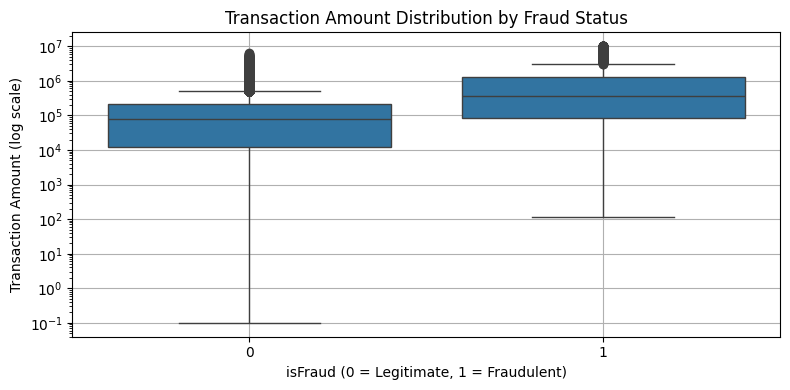

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')  # Helps visualize extreme values
plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("isFraud (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Transaction Amount (log scale)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate average balances for fraudulent transactions
fraudulent = df[df['isFraud'] == 1]
avg_fraudulent = {
    'origin_old_balance': fraudulent['oldbalanceOrg'].mean(),
    'origin_new_balance': fraudulent['newbalanceOrig'].mean(),
    'destination_old_balance': fraudulent['oldbalanceDest'].mean(),
    'destination_new_balance': fraudulent['newbalanceDest'].mean()
}

In [ ]:
# Calculate average balances for non-fraudulent transactions
non_fraudulent = df[df['isFraud'] == 0]
avg_non_fraudulent = {
    'origin_old_balance': non_fraudulent['oldbalanceOrg'].mean(),
    'origin_new_balance': non_fraudulent['newbalanceOrig'].mean(),
    'destination_old_balance': non_fraudulent['oldbalanceDest'].mean(),
    'destination_new_balance': non_fraudulent['newbalanceDest'].mean()
}

In [ ]:
# Combine results
average_balances = {
    'fraudulent': avg_fraudulent,
    'non_fraudulent': avg_non_fraudulent
}

print(average_balances)

{'fraudulent': {'origin_old_balance': np.float64(1218656.1246234677), 'origin_new_balance': np.float64(33944.321208406305), 'destination_old_balance': np.float64(452803.96610332746), 'destination_new_balance': np.float64(1077944.2931523642)}, 'non_fraudulent': {'origin_old_balance': np.float64(873629.7684153639), 'origin_new_balance': np.float64(894742.3462250092), 'destination_old_balance': np.float64(978732.7536447196), 'destination_new_balance': np.float64(1114232.7868357974)}}


In [ ]:
# This cell was reassigning the df variable to a dictionary, causing a KeyError later.
# It has been removed to maintain the DataFrame in the df variable.
# df = {
#     'Origin Old Balance': {'Fraud': 1218656.12, 'Non-Fraud': 873629.77},
#     'Origin New Balance': {'Fraud': 33944.32, 'Non-Fraud': 894742.35},
#     'Destination Old Balance': {'Fraud': 452803.97, 'Non-Fraud': 978732.75},
#     'Destination New Balance': {'Fraud': 1077944.29, 'Non-Fraud': 1114232.79}
# }

In [ ]:
# Create a DataFrame for plotting average balances
df_plot = pd.DataFrame(average_balances)

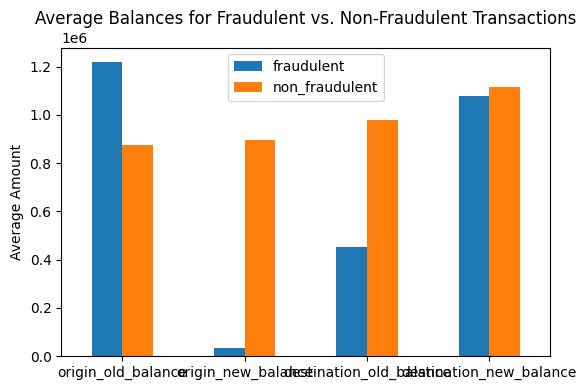

In [ ]:
# Plotting the average balances
df_plot.plot(kind='bar', figsize=(6,4))
plt.title('Average Balances for Fraudulent vs. Non-Fraudulent Transactions')
plt.ylabel('Average Amount')
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
 #Convert the Series to a DataFrame and reset the index
fraud_df = pd.DataFrame(fraud_by_type).reset_index()
fraud_df.columns = ['Transaction Type', 'Fraud Count']

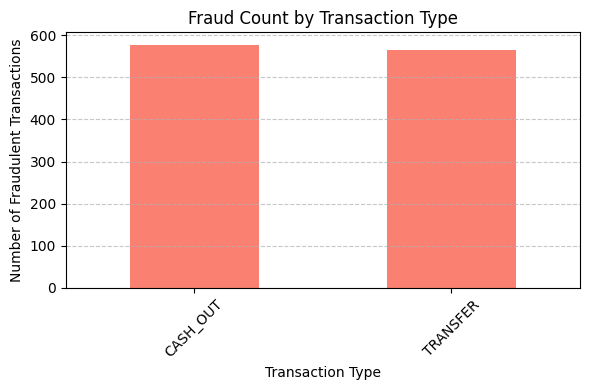

In [ ]:
#Plot the bar chart
ax = fraud_df.plot(kind='bar', x='Transaction Type', y='Fraud Count', figsize=(6, 4), legend=False, color='salmon')
plt.title("Fraud Count by Transaction Type")
plt.ylabel("Number of Fraudulent Transactions")
plt.xlabel("Transaction Type")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#How does the frequency of fraudulent transactions change over time? Can we visualize this trend using a time series plot?
#Filter only fraud transactions
fraud_df = df[df['isFraud'] == 1]
fraud_by_step = fraud_df.groupby('step').size()

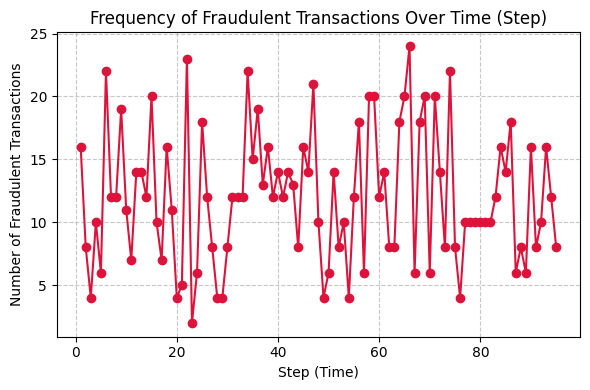

In [ ]:
#Plotting the time series
plt.figure(figsize=(6, 4))
fraud_by_step.plot(kind='line', color='crimson', marker='o')
plt.title("Frequency of Fraudulent Transactions Over Time (Step)")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Fraudulent Transactions")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Filter fraudulent and non-fraudulent transactions
fraudulent = df[df['isFraud'] == 1]
non_fraudulent = df[df['isFraud'] == 0]
# Calculate old and new balances for both types
fraudulent_balances = fraudulent[['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']]
non_fraudulent_balances = non_fraudulent[['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']]
# Calculate mean balances
mean_fraudulent = fraudulent_balances.mean()
mean_non_fraudulent = non_fraudulent_balances.mean()

In [ ]:
# Display the results
print("Mean Balances for Fraudulent Transactions:")
print(mean_fraudulent)
print("\nMean Balances for Non-Fraudulent Transactions:")
print(mean_non_fraudulent)

Mean Balances for Fraudulent Transactions:
oldbalanceOrg     1.218656e+06
newbalanceOrig    3.394432e+04
oldbalanceDest    4.528040e+05
newbalanceDest    1.077944e+06
dtype: float64

Mean Balances for Non-Fraudulent Transactions:
oldbalanceOrg     8.736298e+05
newbalanceOrig    8.947423e+05
oldbalanceDest    9.787328e+05
newbalanceDest    1.114233e+06
dtype: float64


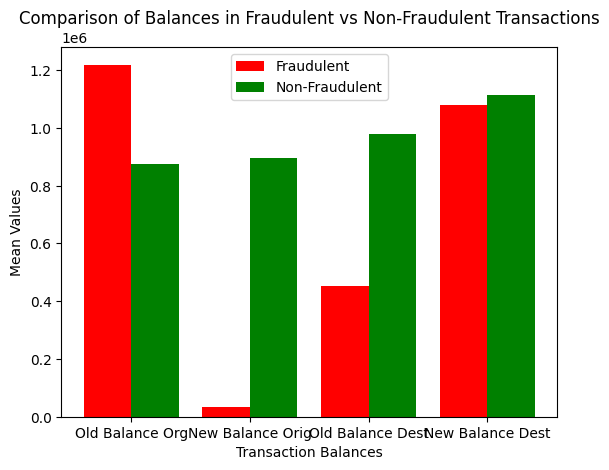

In [ ]:
# Visualize the differences
import matplotlib.pyplot as plt

labels = ['Old Balance Org', 'New Balance Orig', 'Old Balance Dest', 'New Balance Dest']
fraudulent_means = mean_fraudulent.values
non_fraudulent_means = mean_non_fraudulent.values

x = range(len(labels))
plt.bar(x, fraudulent_means, width=0.4, label='Fraudulent', color='red', align='center')
plt.bar([p + 0.4 for p in x], non_fraudulent_means, width=0.4, label='Non-Fraudulent', color='green', align='center')

plt.xlabel('Transaction Balances')
plt.ylabel('Mean Values')
plt.title('Comparison of Balances in Fraudulent vs Non-Fraudulent Transactions')
plt.xticks([p + 0.2 for p in x], labels)
plt.legend()
plt.show()

In [ ]:
#How many unique destination accounts are involved in fraudulent transactions, and what is the average transaction amount for these accounts?
# Filter fraudulent transactions
fraudulent_transactions = df[df['isFraud'] == 1]
# Calculate unique destination accounts and average transaction amount
unique_dest_accounts = fraudulent_transactions['nameDest'].nunique()
average_transaction_amount = fraudulent_transactions['amount'].mean()
print(f"Unique destination accounts involved in fraudulent transactions: {unique_dest_accounts}")
print(f"Average transaction amount for these accounts: {average_transaction_amount}")

Unique destination accounts involved in fraudulent transactions: 1132
Average transaction amount for these accounts: 1192628.9320753065


In [ ]:
import matplotlib.pyplot as plt

# Data to plot
labels = ['Unique Dest Accounts', 'Avg Transaction Amount']
values = [unique_dest_accounts, average_transaction_amount]


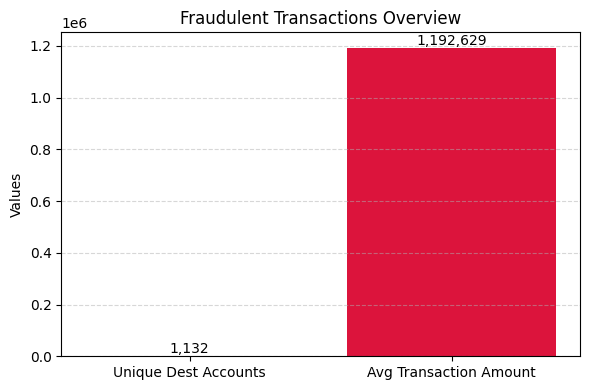

In [ ]:
# Create bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['royalblue', 'crimson'])
# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:,.0f}', ha='center', va='bottom')
# Customize chart
plt.title("Fraudulent Transactions Overview")
plt.ylabel("Values")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
#What is the correlation between transaction amount and the likelihood of fraud? Can we create a scatter plot to visualize this relationship?
# Filter the data for fraud and non-fraud transactions
fraud_data = df[df['isFraud'] == 1]
non_fraud_data = df[df['isFraud'] == 0]

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


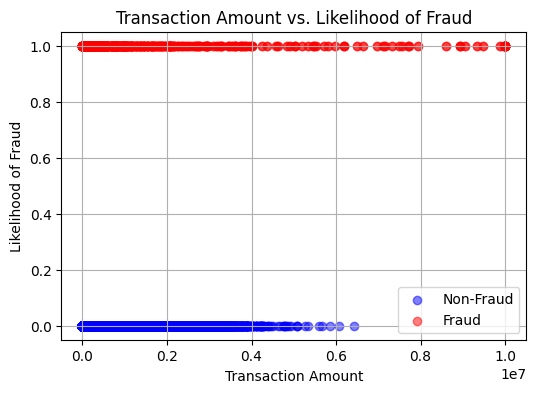

In [ ]:
# Create a scatter plot
plt.figure(figsize=(6,4))
plt.scatter(non_fraud_data['amount'], non_fraud_data['isFraud'], color='blue', label='Non-Fraud', alpha=0.5)
plt.scatter(fraud_data['amount'], fraud_data['isFraud'], color='red', label='Fraud', alpha=0.5)
plt.title('Transaction Amount vs. Likelihood of Fraud')
plt.xlabel('Transaction Amount')
plt.ylabel('Likelihood of Fraud')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Total flagged transactions
total_flagged = df[df['isFlaggedFraud'] == 1]
# Fraudulent flagged transactions
fraud_flagged = total_flagged[total_flagged['isFraud'] == 1]
# Total non-flagged transactions
total_nonflagged = df[df['isFlaggedFraud'] == 0]

# Fraudulent non-flagged transactions
fraud_nonflagged = total_nonflagged[total_nonflagged['isFraud'] == 1]

In [ ]:
# Percentage calculations
percent_fraud_in_flagged = (len(fraud_flagged) / len(total_flagged)) * 100 if len(total_flagged) > 0 else 0
percent_fraud_in_nonflagged = (len(fraud_nonflagged) / len(total_nonflagged)) * 100
print(f"Flagged Transactions: {len(total_flagged)}")
print(f"Fraudulent Flagged Transactions: {len(fraud_flagged)} → {percent_fraud_in_flagged:.4f}%")
print(f"Non-Flagged Transactions: {len(total_nonflagged)}")
print(f"Fraudulent Non-Flagged Transactions: {len(fraud_nonflagged)} → {percent_fraud_in_nonflagged:.4f}%")

Flagged Transactions: 0
Fraudulent Flagged Transactions: 0 → 0.0000%
Non-Flagged Transactions: 1048575
Fraudulent Non-Flagged Transactions: 1142 → 0.1089%


/tmp/ipython-input-33-2509743533.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='amount', data=df, palette='Set2', showfliers=False)


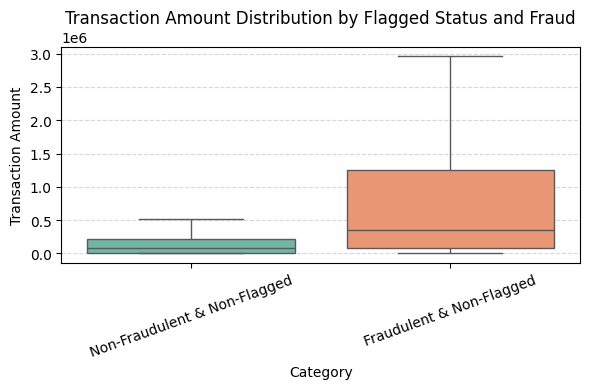

In [ ]:
# Create a 'Category' column based on 'isFraud' and 'isFlaggedFraud'
df['Category'] = 'Non-Fraudulent & Non-Flagged'
df.loc[(df['isFraud'] == 1) & (df['isFlaggedFraud'] == 0), 'Category'] = 'Fraudulent & Non-Flagged'
df.loc[(df['isFraud'] == 0) & (df['isFlaggedFraud'] == 1), 'Category'] = 'Non-Fraudulent & Flagged'
df.loc[(df['isFraud'] == 1) & (df['isFlaggedFraud'] == 1), 'Category'] = 'Fraudulent & Flagged'

# Plotting box plot
plt.figure(figsize=(6,4))
sns.boxplot(x='Category', y='amount', data=df, palette='Set2', showfliers=False)
plt.title("Transaction Amount Distribution by Flagged Status and Fraud")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Group by step and calculate the mean likelihood of fraud
fraud_likelihood = df.groupby('step')['isFraud'].mean()

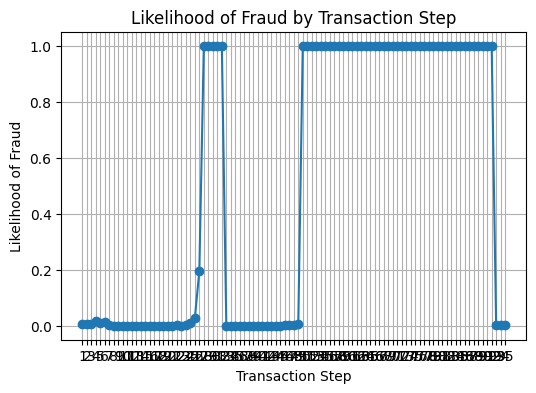

In [ ]:
# Create a line graph
plt.figure(figsize=(6,4))
plt.plot(fraud_likelihood.index, fraud_likelihood.values, marker='o')
plt.title('Likelihood of Fraud by Transaction Step')
plt.xlabel('Transaction Step')
plt.ylabel('Likelihood of Fraud')
plt.grid()
plt.xticks(fraud_likelihood.index)
plt.show()